<a href="https://colab.research.google.com/github/Aleenapshaji/adult_income_predictions/blob/main/assesment_2_heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [133]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Import Linear Regression model
from sklearn.linear_model import LinearRegression
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Import KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier





In [91]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
df_heart = pd.read_csv("/content/drive/MyDrive/AI ML Course/Data/heart_disease.csv")

#EDA

In [93]:
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [94]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [95]:
df_heart.shape

(1025, 14)

In [96]:
df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [97]:
df_heart.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [98]:
df_heart.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [99]:
# Count duplicate records
print("Duplicate Rows:", df_heart.duplicated().sum())

Duplicate Rows: 723


In [100]:
# Select numerical columns
num_cols = df_heart.select_dtypes(include=np.number).columns

# Select categorical columns
cat_cols = df_heart.select_dtypes(include='object').columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Categorical Columns:
Index([], dtype='object')


##PLOTS

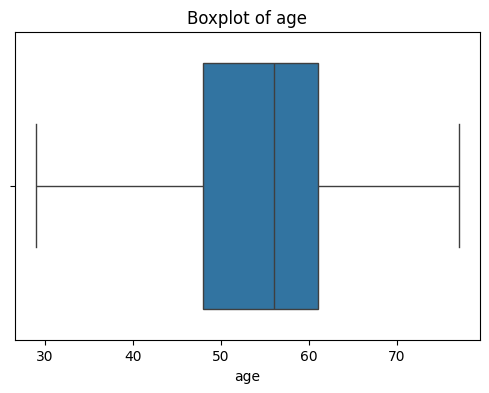

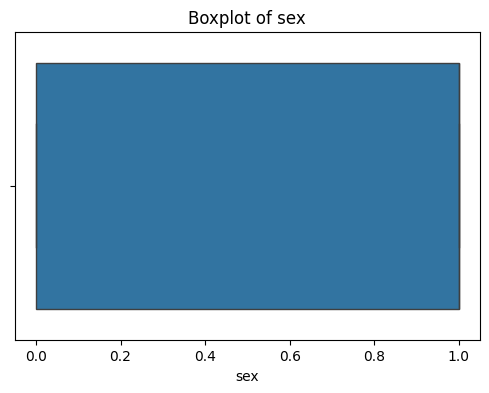

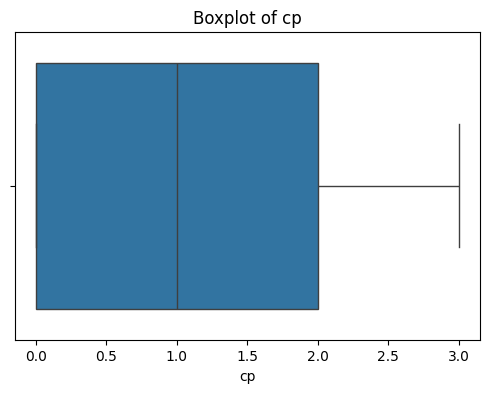

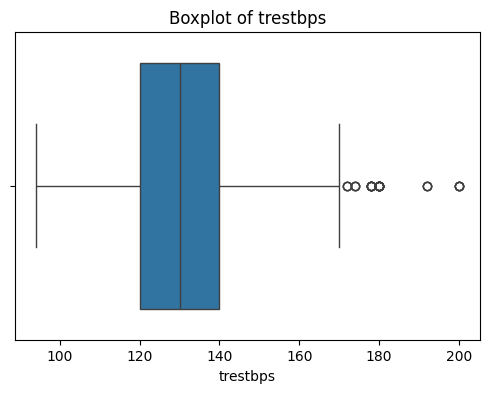

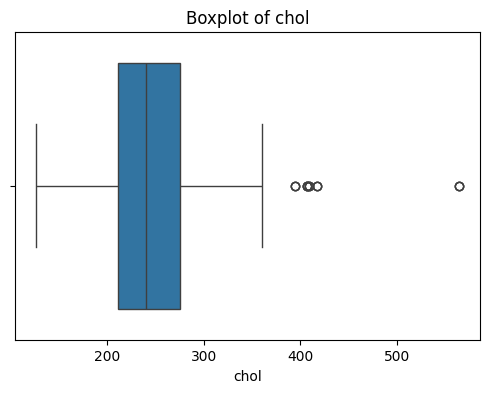

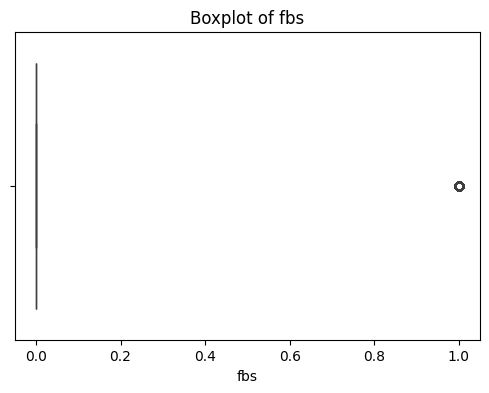

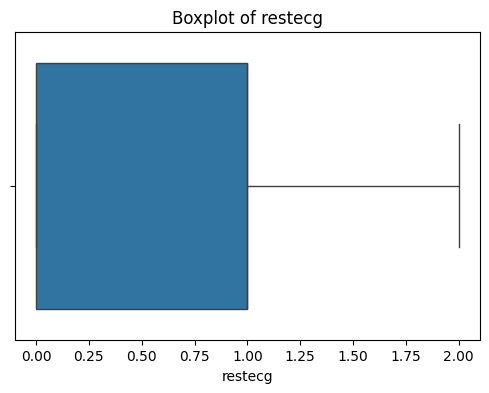

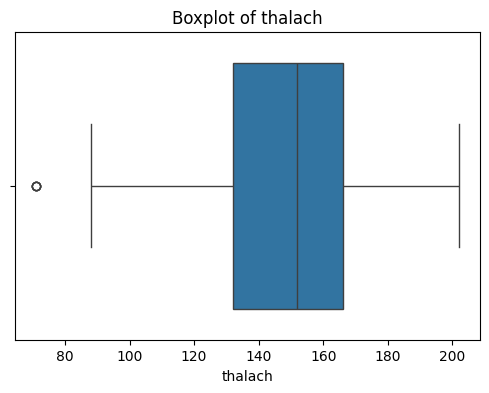

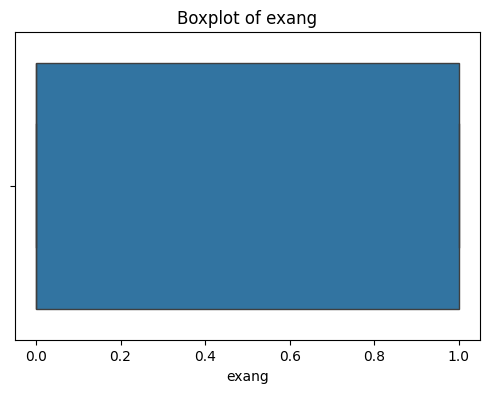

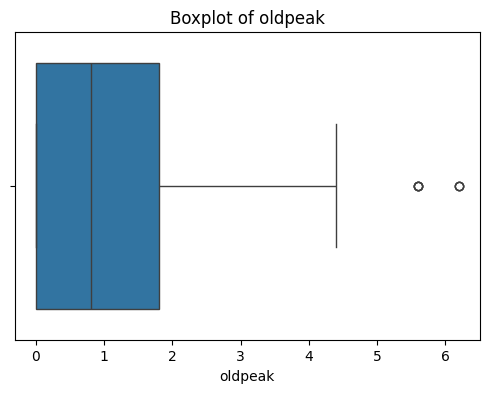

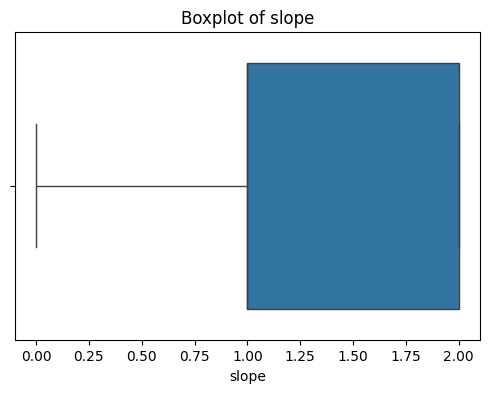

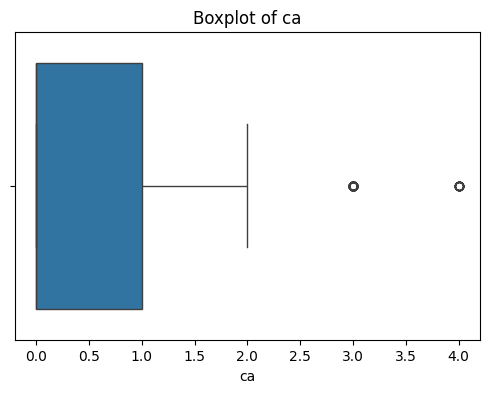

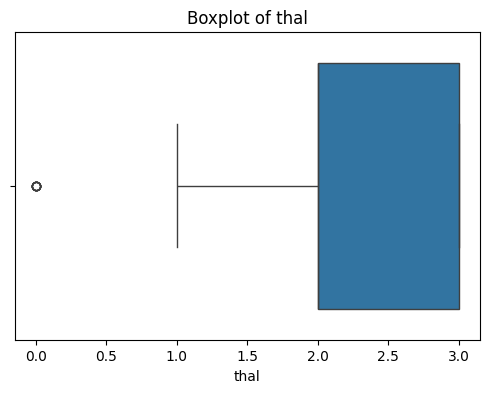

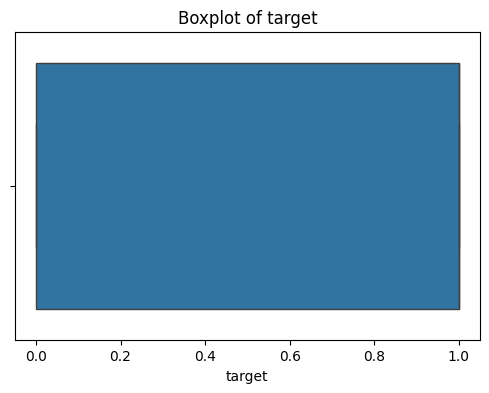

In [101]:
# Boxplots for numerical columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_heart[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [102]:
# Detect outliers using IQR method
for col in num_cols:

    Q1 = df_heart[col].quantile(0.25)
    Q3 = df_heart[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_heart[(df_heart[col] < lower_bound) |
                  (df_heart[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")


age: 0 outliers
sex: 0 outliers
cp: 0 outliers
trestbps: 30 outliers
chol: 16 outliers
fbs: 153 outliers
restecg: 0 outliers
thalach: 4 outliers
exang: 0 outliers
oldpeak: 7 outliers
slope: 0 outliers
ca: 87 outliers
thal: 7 outliers
target: 0 outliers


In [103]:
# Frequency distribution of categorical variables
for col in cat_cols:
    print("\nColumn:", col)
    print(df_heart[col].value_counts())

In [104]:
# Countplots for categorical variables
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df_heart[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

#Preproocessing

##Handling missing value

In [105]:
# Select numerical columns
num_cols = df_heart.select_dtypes(include=np.number).columns

# Replace missing numerical values with median
for col in num_cols:
    df_heart[col] = df_heart[col].fillna(df_heart[col].median())# Median is preferred because it is less affected by outliers.

In [106]:
# Select categorical columns
cat_cols = df_heart.select_dtypes(include='object').columns

# Replace missing categorical values with mode
for col in cat_cols:
    df_heart[col].fillna(df_heart[col].mode()[0], inplace=True) ## Mode replaces missing values with the most frequent category.

In [107]:
# Numerical columns for outlier treatment
outlier_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']

In [108]:
# Apply IQR method to cap outliers
for col in outlier_cols:

    Q1 = df_heart[col].quantile(0.25)
    Q3 = df_heart[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_heart[col] = np.where(
        df_heart[col] < lower_limit,
        lower_limit,
        np.where(
            df_heart[col] > upper_limit,
            upper_limit,
            df_heart[col]
        )
    )                                                  # IQR method reduces the impact of extreme values without removing records.

In [109]:
# Verify binary variables
print(df_heart['sex'].unique())
print(df_heart['fbs'].unique())    # No encoding is needed because these columns already contain binary values.

[1 0]
[0 1]


###one hot Encoding

In [110]:
# Apply one-hot encoding
df_heart = pd.get_dummies(
    df_heart,
    columns=['cp', 'restecg', 'thal'],
    drop_first=True
)

In [111]:
print(df_heart.columns)

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1',
       'restecg_2', 'thal_1', 'thal_2', 'thal_3'],
      dtype='object')


###Scaling

In [112]:

# Features selected for scaling
scale_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']

# Create scaler object
scaler = StandardScaler()

# Apply scaling
df_heart[scale_cols] = scaler.fit_transform(
    df_heart[scale_cols]
)

In [113]:
# Display first five rows
df_heart.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,-0.378869,-0.691104,0,0.824084,0,-0.054537,2,2,0,False,False,False,True,False,False,False,True
1,53,1,0.528894,-0.879693,1,0.255654,1,1.785457,0,0,0,False,False,False,False,False,False,False,True
2,70,1,0.831481,-1.487368,0,-1.056105,1,1.347363,0,0,0,False,False,False,True,False,False,False,True
3,61,1,1.013034,-0.879693,0,0.518006,0,-0.930725,2,1,0,False,False,False,True,False,False,False,True
4,62,0,0.407859,1.027150,1,-1.886886,0,0.734031,1,3,0,False,False,False,True,False,False,True,False


In [114]:
# Check dataset shape after preprocessing
print(df_heart.shape)

(1025, 19)


#Model Building

In [115]:
# Regression Task:
# Predict serum cholesterol levels using all remaining features.

# Classification Task:
# Predict the presence or absence of heart disease using all remaining features.

# The dataset is split into 80% training data and 20% testing data.
# Training data is used to train the model.
# Testing data is used to evaluate model performance on unseen data.

###Regression: Predict Serum Cholesterol (chol)

In [116]:

# Features are all columns except cholesterol
X_reg = df_heart.drop('chol', axis=1)

# Target variable is cholesterol
y_reg = df_heart['chol']

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)



In [117]:
# Display shapes
print("Regression Training Features:", X_train_reg.shape)
print("Regression Testing Features:", X_test_reg.shape)
print("Regression Training Target:", y_train_reg.shape)
print("Regression Testing Target:", y_test_reg.shape)

Regression Training Features: (820, 18)
Regression Testing Features: (205, 18)
Regression Training Target: (820,)
Regression Testing Target: (205,)


###Classification: Predict Heart Disease (target)

In [118]:
from sklearn.model_selection import train_test_split

# Features are all columns except target
X_clf = df_heart.drop('target', axis=1)

# Target variable is heart disease presence
y_clf = df_heart['target']

# Split data into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)



In [119]:
# Display shapes
print("Classification Training Features:", X_train_clf.shape)
print("Classification Testing Features:", X_test_clf.shape)
print("Classification Training Target:", y_train_clf.shape)
print("Classification Testing Target:", y_test_clf.shape)

Classification Training Features: (820, 18)
Classification Testing Features: (205, 18)
Classification Training Target: (820,)
Classification Testing Target: (205,)


#Build Machine Learning Models

##Regression Task: Predict chol (Serum Cholesterol)

###
1. Linear Regression

In [120]:

# Create Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_reg, y_train_reg)

# Predict cholesterol values
lr_pred = lr_model.predict(X_test_reg)

In [121]:
print("Linear Regression Results")
print("MAE :", mean_absolute_error(y_test_reg, lr_pred))
print("MSE :", mean_squared_error(y_test_reg, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, lr_pred)))
print("R2 Score :", r2_score(y_test_reg, lr_pred))

Linear Regression Results
MAE : 0.7935053018989049
MSE : 1.0071831374768538
RMSE : 1.0035851421164295
R2 Score : 0.051953735725618455


###
2.Support Vector Regression (SVR)

In [122]:

# Create SVR model
svr_model = SVR()

# Train the model
svr_model.fit(X_train_reg, y_train_reg)

# Predict cholesterol values
svr_pred = svr_model.predict(X_test_reg)

In [123]:
print("SVR Results")
print("MAE :", mean_absolute_error(y_test_reg, svr_pred))
print("MSE :", mean_squared_error(y_test_reg, svr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, svr_pred)))
print("R2 Score :", r2_score(y_test_reg, svr_pred))

SVR Results
MAE : 0.8177635203356489
MSE : 1.0502768012554988
RMSE : 1.0248301328783707
R2 Score : 0.011390321348380028


###
3.Random Forest Regressor

In [124]:


# Create Random Forest model
rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_reg_model.fit(X_train_reg, y_train_reg)

# Predict cholesterol values
rf_reg_pred = rf_reg_model.predict(X_test_reg)

In [125]:
print("Random Forest Regression Results")
print("MAE :", mean_absolute_error(y_test_reg, rf_reg_pred))
print("MSE :", mean_squared_error(y_test_reg, rf_reg_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, rf_reg_pred)))
print("R2 Score :", r2_score(y_test_reg, rf_reg_pred))

Random Forest Regression Results
MAE : 0.17487756702078294
MSE : 0.07362466214371476
RMSE : 0.27133864845192024
R2 Score : 0.9306982183213762


In [136]:
#comparison of regression model
reg_results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR", "Random Forest"],
    "R2 Score": [
        r2_score(y_test_reg, lr_pred),
        r2_score(y_test_reg, svr_pred),
        r2_score(y_test_reg, rf_reg_pred)
    ]
})

print(reg_results)

               Model  R2 Score
0  Linear Regression  0.051954
1                SVR  0.011390
2      Random Forest  0.930698


##Classification Task: Predict target (Heart Disease)

###
1. Logistic Regression

In [127]:
# Create Logistic Regression model
log_model = LogisticRegression()
# Train the model
log_model.fit(X_train_clf, y_train_clf)

# Predict heart disease
log_pred = log_model.predict(X_test_clf)





/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [129]:

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test_clf, log_pred))
print("Precision :", precision_score(y_test_clf, log_pred))
print("Recall :", recall_score(y_test_clf, log_pred))
print("F1 Score :", f1_score(y_test_clf, log_pred))

Logistic Regression Results
Accuracy : 0.8195121951219512
Precision : 0.775
Recall : 0.9029126213592233
F1 Score : 0.8340807174887892


###
2.KNN

In [131]:


# Create KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model
knn_model.fit(X_train_clf, y_train_clf)

# Predict heart disease
knn_pred = knn_model.predict(X_test_clf)

In [132]:
print("KNN Results")
print("Accuracy :", accuracy_score(y_test_clf, knn_pred))
print("Precision :", precision_score(y_test_clf, knn_pred))
print("Recall :", recall_score(y_test_clf, knn_pred))
print("F1 Score :", f1_score(y_test_clf, knn_pred))

KNN Results
Accuracy : 0.8439024390243902
Precision : 0.8817204301075269
Recall : 0.7961165048543689
F1 Score : 0.8367346938775511


###
3.Random Forest Classifier

In [134]:


# Create Random Forest model
rf_clf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_clf_model.fit(X_train_clf, y_train_clf)

# Predict heart disease
rf_clf_pred = rf_clf_model.predict(X_test_clf)

In [135]:
print("Random Forest Classification Results")
print("Accuracy :", accuracy_score(y_test_clf, rf_clf_pred))
print("Precision :", precision_score(y_test_clf, rf_clf_pred))
print("Recall :", recall_score(y_test_clf, rf_clf_pred))
print("F1 Score :", f1_score(y_test_clf, rf_clf_pred))

Random Forest Classification Results
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


In [137]:
#comparison of classification model
clf_results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test_clf, log_pred),
        accuracy_score(y_test_clf, knn_pred),
        accuracy_score(y_test_clf, rf_clf_pred)
    ]
})

print(clf_results)

                 Model  Accuracy
0  Logistic Regression  0.819512
1                  KNN  0.843902
2        Random Forest  1.000000


#Evaluate Models on Test Data